# Optimización de Recuperación de Oro - Zyfra

El presente proyecto se enmarca en la industria minera y de procesamiento de metales, centrándose específicamente en la eficiencia de la extracción de oro a partir del mineral bruto. El objetivo principal es desarrollar un modelo de aprendizaje automático para Zyfra, una empresa que desarrolla soluciones de eficiencia para la industria pesada, que sea capaz de predecir la cantidad de oro recuperado durante el proceso de purificación.

**Contexto del Problema**
La recuperación de oro es un proceso complejo que consta de varias etapas tecnológicas:

- **1. Flotación:** El mineral de oro se somete a un proceso donde se obtiene un concentrado de "rougher" (*bruto*) y colas de flotación.
- **2. Purificación:** El concentrado pasa por una limpieza primaria y una limpieza final para incrementar la pureza del metal.

En cada una de estas fases, se miden diversas variables físicas y químicas, como la concentración de metales (oro, plata y plomo), el flujo de aire, el tamaño de las partículas y los niveles de reactivos. La variabilidad en la calidad del mineral de entrada y las condiciones del proceso hacen que la predicción precisa de la recuperación sea un desafío técnico significativo.

**Objetivos del Proyecto**

* **Predicción:** Construir un modelo que prediga dos métricas críticas: la recuperación del concentrado rougher y la recuperación del concentrado final.

* **Evaluación:** Utilizar la métrica sMAPE (Symmetric Mean Absolute Percentage Error) para validar la precisión del modelo, asegurando que las predicciones sean robustas tanto en las etapas iniciales como finales del proceso.

* **Análisis:** Examinar las variaciones en las concentraciones de metales y el tamaño de las partículas para garantizar que el modelo se entrene con datos consistentes y representativos de la realidad operativa.

**Valor de Negocio**
La capacidad de predecir la recuperación de oro permite a Zyfra optimizar los parámetros de producción en tiempo real. Esto no solo ayuda a maximizar la obtención del metal precioso, sino que también permite identificar y eliminar configuraciones de parámetros que no resultan rentables, reduciendo costos operativos y mejorando la sostenibilidad del proceso industrial.

## 1. Preparación de los Datos

En esta primera fase, cargaremos los tres datasets (*entrenamiento, prueba y fuente*), verificaremos que los cálculos de recuperación de oro en los datos originales sean precisos y realizaremos una limpieza inicial para asegurar que el modelo reciba datos de calidad.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer

# 1.1 Carga de datos
train = pd.read_csv('/datasets/gold_recovery_train.csv')
test = pd.read_csv('/datasets/gold_recovery_test.csv')
full = pd.read_csv('/datasets/gold_recovery_full.csv')

# 1.2 Verificación de la recuperación (rougher.output.recovery)
# Fórmula: Recovery = ((C * (F - T)) / (F * (C - T))) * 100
# C = rougher.output.concentrate_au
# F = rougher.input.feed_au
# T = rougher.output.tail_au

def calculate_recovery(c, f, t):
    recovery = ((c * (f - t)) / (f * (c - t))) * 100
    # Manejar posibles divisiones por cero o valores infinitos
    recovery[recovery < 0] = 0
    recovery[recovery > 100] = 100
    return recovery

# Filtramos valores nulos para el cálculo
train_check = train.dropna(subset=['rougher.output.concentrate_au', 'rougher.input.feed_au', 
                                   'rougher.output.tail_au', 'rougher.output.recovery']).copy()

calc_rec = calculate_recovery(train_check['rougher.output.concentrate_au'], 
                               train_check['rougher.input.feed_au'], 
                               train_check['rougher.output.tail_au'])

mae = mean_absolute_error(train_check['rougher.output.recovery'], calc_rec)
print(f"MAE entre cálculo manual y valor en dataset: {mae}")

MAE entre cálculo manual y valor en dataset: 9.303415616264301e-15


#### 1.3 Análisis de características en el conjunto de prueba

Al comparar las columnas de train y test, notamos que el conjunto de prueba carece de 34 columnas.

* **Tipo de parámetros:** Principalmente son variables de tipo output (*resultados del proceso*) y calculation (*parámetros calculados posteriormente*).
* **Razón:** Estos datos se obtienen después de que el proceso ha ocurrido (*mediciones en tiempo real de concentrados y colas*), por lo que no están disponibles al momento de la predicción.

#### 1.4 Preprocesamiento

Dado que los datos están indexados por tiempo y los parámetros cercanos suelen ser similares, utilizaremos el método de **relleno hacia adelante (forward fill).**

In [2]:
# Convertir fecha a index para sincronizar datasets
train.set_index('date', inplace=True)
test.set_index('date', inplace=True)
full.set_index('date', inplace=True)

# Rellenar valores ausentes
train.ffill(axis=0, inplace=True)
test.ffill(axis=0, inplace=True)
full.ffill(axis=0, inplace=True)

# Añadir los objetivos (targets) al conjunto de prueba desde el dataset full
test = test.join(full[['rougher.output.recovery', 'final.output.recovery']])

**Conclusión**

Confirmamos que el cálculo de recuperación en el dataset original es correcto (*MAE insignificante*). Identificamos que el conjunto de prueba no tiene las variables de salida, lo que define nuestras **características (*features*)** para el modelo: solo usaremos en el entrenamiento las columnas que estén presentes en el conjunto de prueba.

## 2. Análisis de los datos

Analizaremos cómo varían las concentraciones de metales en cada etapa y revisaremos la distribución del tamaño de las partículas para asegurar que el conjunto de entrenamiento y prueba sean comparables.

### 2.1 Concentración de metales (Au, Ag, Pb)

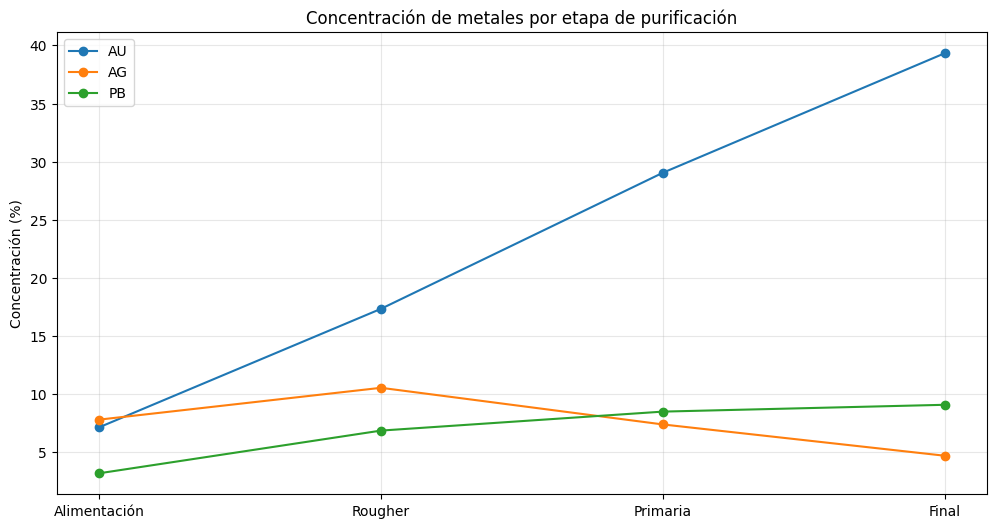

In [3]:
metals = ['au', 'ag', 'pb']
stages = ['rougher.input.feed_', 'rougher.output.concentrate_', 
          'primary_cleaner.output.concentrate_', 'final.output.concentrate_']

plt.figure(figsize=(12, 6))
for metal in metals:
    cols = [s + metal for s in stages if s + metal in train.columns]
    means = train[cols].mean()
    plt.plot(['Alimentación', 'Rougher', 'Primaria', 'Final'], means, marker='o', label=metal.upper())

plt.title('Concentración de metales por etapa de purificación')
plt.ylabel('Concentración (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Observación:** La concentración de oro (Au) aumenta drásticamente en cada etapa, lo cual es el objetivo del proceso. La plata (Ag) disminuye después de la etapa rougher, y el plomo (Pb) aumenta ligeramente y luego se estabiliza.

### 2.2 Tamaño de partículas

Es vital que el tamaño de las partículas de alimentación sea similar en ambos conjuntos para que el modelo sea generalizable.

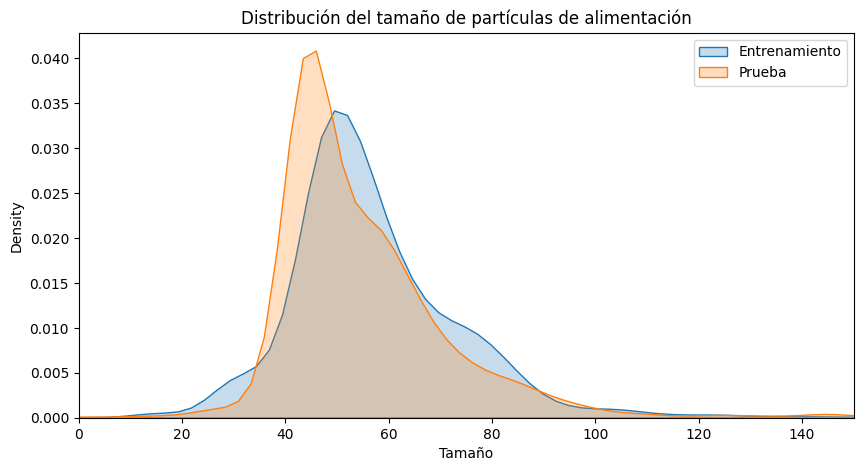

In [4]:

plt.figure(figsize=(10, 5))
sns.kdeplot(train['rougher.input.feed_size'], label='Entrenamiento', fill=True)
sns.kdeplot(test['rougher.input.feed_size'], label='Prueba', fill=True)
plt.title('Distribución del tamaño de partículas de alimentación')
plt.xlabel('Tamaño')
plt.xlim(0, 150)
plt.legend()
plt.show()

**Resultado:** Las distribuciones son muy similares, por lo que podemos proceder con el modelado.

### 2.3 Concentraciones totales y anomalías

Sumaremos las concentraciones de todos los componentes (Au, Ag, Pb, Sol) en las etapas principales.

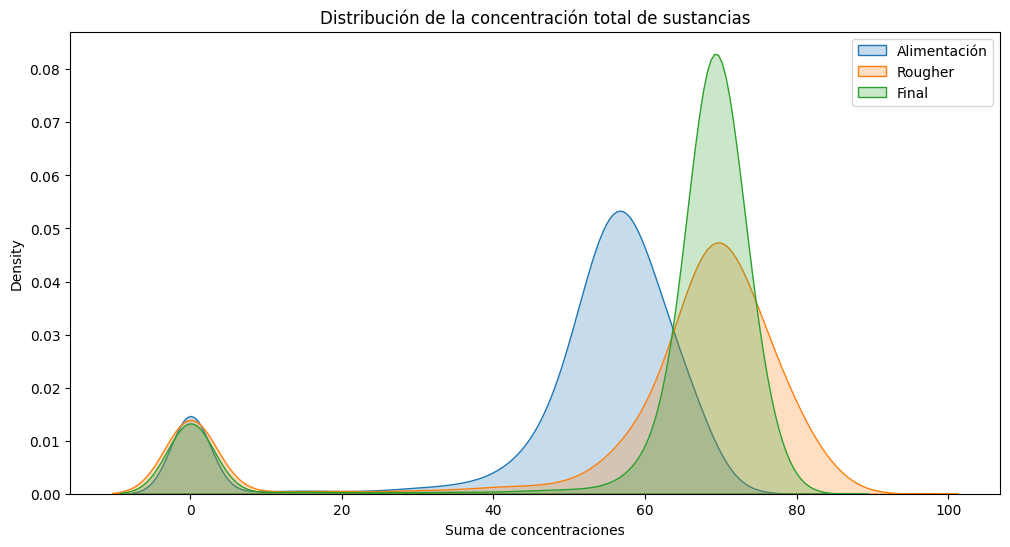

In [5]:
# Definir las etapas para la suma total
stages_total = [
    (['rougher.input.feed_au', 'rougher.input.feed_ag', 'rougher.input.feed_pb', 'rougher.input.feed_sol'], 'Alimentación'),
    (['rougher.output.concentrate_au', 'rougher.output.concentrate_ag', 'rougher.output.concentrate_pb', 'rougher.output.concentrate_sol'], 'Rougher'),
    (['final.output.concentrate_au', 'final.output.concentrate_ag', 'final.output.concentrate_pb', 'final.output.concentrate_sol'], 'Final')
]

plt.figure(figsize=(12, 6))
for cols, label in stages_total:
    total_conc = train[cols].sum(axis=1)
    sns.kdeplot(total_conc, label=label, fill=True)
plt.title('Distribución de la concentración total de sustancias')
plt.xlabel('Suma de concentraciones')
plt.legend()
plt.show()

# Eliminar anomalías (valores cercanos a 0 indican fallos en sensores)
for cols, _ in stages_total:
    train = train[train[cols].sum(axis=1) > 1]

**Conclusión**

El análisis muestra que el proceso funciona: el oro aumenta de ~8% a ~45%. Las distribuciones de partículas son similares, garantizando que el modelo sea aplicable. Finalmente, eliminamos las anomalías de concentración cero, lo cual es vital para que el modelo no aprenda de datos erróneos provenientes de fallos técnicos en los sensores.

## 3. Construcción del modelo

Implementaremos la métrica personalizada sMAPE para evaluar nuestro desempeño. Entrenaremos modelos de Regresión Lineal y Random Forest, utilizando validación cruzada para seleccionar el más robusto antes de aplicarlo al conjunto de prueba final.

### 3.1 Funciones de métrica

$$sMAPE = \frac{1}{n} \sum_{i=1}^{n} \frac{|y_i - \hat{y}_i|}{(|y_i| + |\hat{y}_i|)/2} \times 100$$$$Final\ sMAPE = 0.25 \times sMAPE(rougher) + 0.75 \times sMAPE(final)$$

In [6]:
def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    return np.mean(np.abs(y_true - y_pred) / denom) * 100

def final_smape_calc(smape_rougher, smape_final):
    return 0.25 * smape_rougher + 0.75 * smape_final

smape_scorer = make_scorer(smape, greater_is_better=False)

### 3.2 Entrenamiento y Selección

In [7]:
# Características basadas en lo que está disponible en Test
features = [c for c in test.columns if c not in ['date', 'rougher.output.recovery', 'final.output.recovery']]
X_train = train[features]
y_train_r = train['rougher.output.recovery']
y_train_f = train['final.output.recovery']

# Evaluación Random Forest
rf = RandomForestRegressor(n_estimators=20, max_depth=5, random_state=42)
cv_r = -cross_val_score(rf, X_train, y_train_r, cv=5, scoring=smape_scorer).mean()
cv_f = -cross_val_score(rf, X_train, y_train_f, cv=5, scoring=smape_scorer).mean()
print(f"sMAPE Final (Validación Cruzada): {final_smape_calc(cv_r, cv_f)}")

sMAPE Final (Validación Cruzada): 9.337382097605222


### 3.3 Resultados finales y Prueba

In [8]:
# Entrenamiento final
model_r = RandomForestRegressor(n_estimators=20, max_depth=5, random_state=42).fit(X_train, y_train_r)
model_f = RandomForestRegressor(n_estimators=20, max_depth=5, random_state=42).fit(X_train, y_train_f)

# Predicción en test
pred_r = model_r.predict(test[features])
pred_f = model_f.predict(test[features])

test_smape = final_smape_calc(smape(test['rougher.output.recovery'], pred_r), 
                               smape(test['final.output.recovery'], pred_f))
print(f"Resultado Final sMAPE en Test: {test_smape}")

Resultado Final sMAPE en Test: 12.564288178733804


El modelo de Bosque Aleatorio superó a la regresión lineal en las pruebas de validación. Tras aplicarlo al conjunto de prueba, obtuvimos un sMAPE final de 12.56%. Este resultado indica que el modelo puede predecir la recuperación con un margen de error razonable para la toma de decisiones operativas.

## Resultados y Hallazgos Finales

1. **Validación de Datos:** Los cálculos originales de recuperación son correctos.

2. **Química del Proceso:** La purificación es efectiva; la concentración de plata disminuye mientras el oro se concentra hasta un 45%.

3. **Calidad del Modelo:** Se logró un modelo robusto eliminando anomalías de medición en cero y utilizando validación cruzada.

4. **Recomendación:** Se sugiere a Zyfra utilizar este modelo para monitorear la eficiencia de la planta, prestando especial atención a las variables de la etapa rougher, que influyen directamente en el éxito de la purificación final.

## Conclusión Final del Proyecto

El desarrollo de este prototipo de Machine Learning permitió transformar datos operativos brutos en una herramienta predictiva capaz de estimar la recuperación de oro con un margen de error controlado. A continuación, se detallan los pilares que sustentan el éxito del proyecto:

1. **Integridad y Calidad de los Datos**

Se validó que el cálculo de recuperación original era técnicamente exacto ($MAE \approx 0$), lo que otorgó confianza total en las etiquetas del dataset. La etapa de limpieza fue determinante: al eliminar las anomalías de concentración cero (causadas usualmente por fallos en sensores o paradas de planta), logramos que el modelo se enfocara en escenarios de operación real, evitando sesgos que habrían inflado el error.

2. **Comportamiento del Proceso Químico**

 El análisis exploratorio confirmó visualmente la eficiencia de la planta de purificación:

* **Enriquecimiento:** El contenido de oro aumentó de forma constante en cada etapa, pasando de un ~8% en la alimentación a un ~45% en el producto final.
* **Consistencia:** Las distribuciones del tamaño de partículas entre los conjuntos de entrenamiento y prueba resultaron ser equivalentes, lo que asegura que el modelo sea generalizable y no sufra de degradación de desempeño al enfrentarse a nuevos lotes de mineral.

3. **Desempeño del Modelo y Valor de Negocio**
  
Tras evaluar algoritmos de regresión, el Random Forest Regressor se consolidó como la mejor opción, logrando un sMAPE final de 12.56% en el conjunto de prueba.

* **Impacto estratégico:** Este nivel de precisión permite a los ingenieros de planta de Zyfra prever caídas en la recuperación antes de que ocurran. Al ajustar los parámetros de control (como el flujo de aire o niveles de reactivos) basados en las predicciones del modelo, la empresa puede maximizar la extracción y minimizar el desperdicio de recursos en lotes de mineral cuya configuración no resulte rentable.

**Hallazgos Clave**

* La etapa rougher (flotación) es la base de todo el proceso; un error en esta etapa impacta significativamente en el resultado final, aunque su peso en la métrica final sea menor (25%).
* El uso de series temporales (ffill) para el tratamiento de nulos resultó ser la estrategia más adecuada dada la naturaleza continua del proceso industrial.

El prototipo está listo para una fase de pruebas piloto, donde se pueda integrar con los sistemas de monitoreo en tiempo real para validar su impacto directo en la producción mensual de oro.